# Toric code NES test

This notebook tests the sampled NES implementation on the 2D toric code. The toric code lives on **edges**, so `shape=(Lx,Ly)` means `N_edges=2*Lx*Ly` spin variables. On a torus, the ground state is four-fold degenerate.


In [1]:
import jax
print(jax.devices())

[CudaDevice(id=0)]


In [2]:
import time
import jax
import jax.numpy as jnp

print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())

# Force the array onto the first GPU if available
device = jax.devices("gpu")[0]

x = jax.device_put(jnp.ones((5000, 5000)), device)

t0 = time.time()
y = x @ x
y.block_until_ready()
t1 = time.time()

print("result device:", y.device)
print("backend used:", y.device.platform)
print("time:", round(t1 - t0, 3), "s")

JAX backend: gpu
JAX devices: [CudaDevice(id=0)]
result device: cuda:0
backend used: gpu
time: 3.85 s


In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.home() / "Desktop" / "Master Thesis" / "nes_lattice_project"
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from nes_lattice.train import TrainConfig, train, save_history
from nes_lattice.hamiltonians import make_hamiltonian_spec
from nes_lattice.references import get_reference_energies
from nes_lattice.plots import plot_history, plot_diagnostics, print_final

PROJECT_ROOT


PosixPath('/home/a/Anas.Roumeih/Desktop/Master Thesis/nes_lattice_project')

## Check toric-code terms and exact ground degeneracy

In [4]:
hspec = make_hamiltonian_spec(name='toric_code', shape=(2, 2), Je=1.0, Jm=1.0, pbc=True)
terms = hspec.bonds_np
stars, plaquettes = terms[0], terms[1]
print('shape:', hspec.shape)
print('edge spins N:', hspec.N)
print('number of stars:', len(stars))
print('number of plaquettes:', len(plaquettes))
print('first star:', stars[0])
print('first plaquette:', plaquettes[0])

ref, msg = get_reference_energies(hspec, k=4, prefer='auto')
print('reference source:', msg)
print('first 4 reference energies:', ref)


shape: (2, 2)
edge spins N: 8
number of stars: 4
number of plaquettes: 4
first star: [0 4 1 3]
first plaquette: [0 5 2 1]
reference source: toric_code_exact_4fold_ground_degeneracy
first 4 reference energies: [-8. -8. -8. -8.]


## Example A: 2x2 toric code, k=4, FFN

This is the first correctness test. Since `N_edges=8`, exact span evaluation and dense ED are cheap. The target is four energies close to `-8` for `Je=Jm=1`.


In [5]:
cfg = TrainConfig(
    shape=(2, 2),
    hamiltonian='toric_code',
    k=5,
    Je=1.0,
    Jm=1.0,
    model='ffn',
    hidden=(64, 64),
    steps=5000,
    lr=5e-3,
    n_chains=96,
    n_samples=8,
    print_every=100,
    eval_exact_if_sites_leq=12,
    reference='auto',
    seed=0,
)

params, history = train(cfg)

save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_4x4_k5_ffn.json'
save_history(history, save_path, cfg)

print('saved to:', save_path)


{'step': 0, 'loss_sum': -4.106750014214591, 'train_energy_estimator': nan, 'energies': [-4.001491635571811, -0.10103448814915521, -0.005469701948540172, -0.002495063755942533, 0.0037408752108575084], 'reference': [-8.000000000000005, -7.999999999999999, -7.999999999999998, -7.999999999999994, -4.000000000000005], 'reference_source': 'own_dense_ed', 'abs_errors': [3.9985083644281945, 7.898965511850844, 7.994530298051458, 7.997504936244051, 4.0037408752108625], 'trace_error': 31.89324998578541, 'condition_number_S': 237166.530929171, 'sampler_accept_rate': nan, 'grad_norm': nan, 'eval': {'S_min_eig': 3.238303852337226e-06, 'S_max_eig': 0.7680172907533902, 'S_rank': 5, 'S_floor': 1e-06, 'S_num_clipped': 0, 'S_eigenvalues': [3.238303852337226e-06, 4.1435257907105285e-06, 6.192836010840933e-06, 1.2493499886573955e-05, 0.7680172907533902], 'method': 'exact_span', 'accept_rate': None}}
{'step': 100, 'loss_sum': -4.019204549686669, 'train_energy_estimator': -4.203100204467773, 'energies': [-3.

File:               /home/a/Anas.Roumeih/Desktop/Master Thesis/nes_lattice_project/results/sampled_nes_toric_4x4_k5_ffn.json
Config:             {'shape': [2, 2], 'hamiltonian': 'toric_code', 'k': 5, 'J': 1.0, 'g': 1.0, 'Je': 1.0, 'Jm': 1.0, 'pbc': True, 'magnetization': None, 'model': 'ffn', 'hidden': [64, 64], 'rbm_hidden': 32, 'channels': [16, 16], 'kernel_size': 3, 'init_scale': 0.05, 'dtype': 'float32', 'steps': 5000, 'lr': 0.005, 'n_chains': 96, 'n_samples': 8, 'sweep_steps': 8, 'burn_in': 80, 'det_jitter': 1e-06, 'grad_clip': 10.0, 'print_every': 100, 'eval_exact_if_sites_leq': 12, 'eval_samples': 32, 'eval_chains': 128, 'reference': 'auto', 'own_ed_max_sites': 14, 'netket_max_states': 2000000, 'jitter': 1e-06, 'seed': 0}
Final NES energies: [-7.7524971947860095, -3.9827815439754666, -3.9728841797071315, -3.9491244884972696, -3.7462490660809395]
Reference:          [-8.000000000000005, -7.999999999999999, -7.999999999999998, -7.999999999999994, -4.000000000000005]
Reference sour

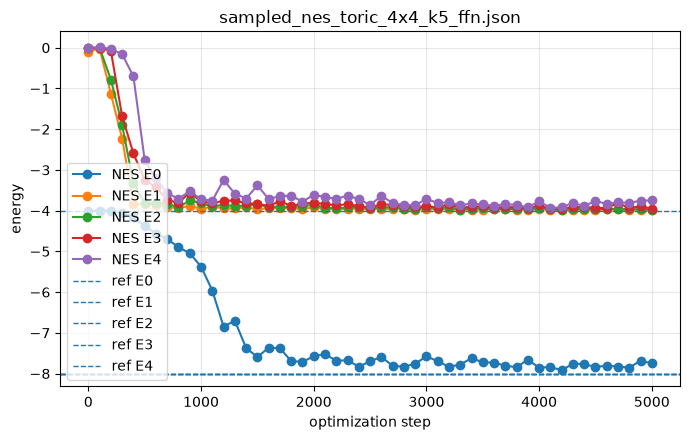

In [6]:
print_final(save_path)
fig, ax = plot_history(save_path)


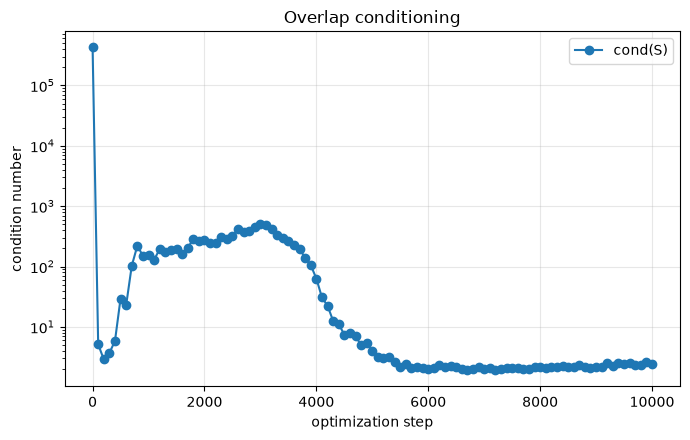

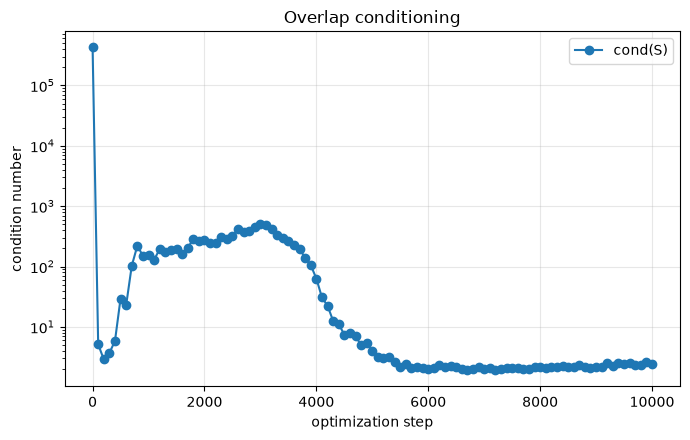

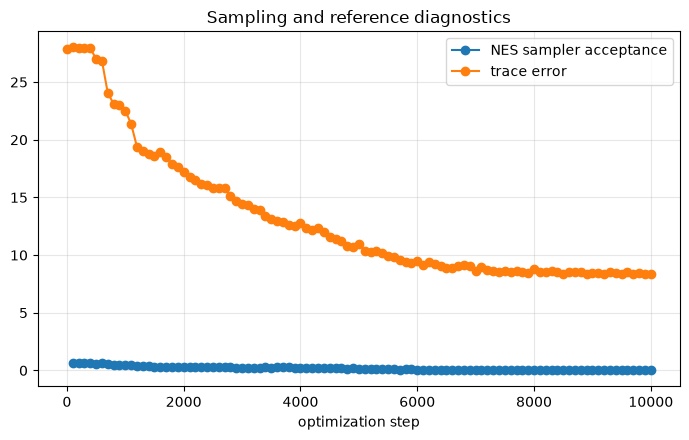

In [10]:
(fig_cond, ax_cond), (fig_diag, ax_diag) = plot_diagnostics(save_path)
fig_cond


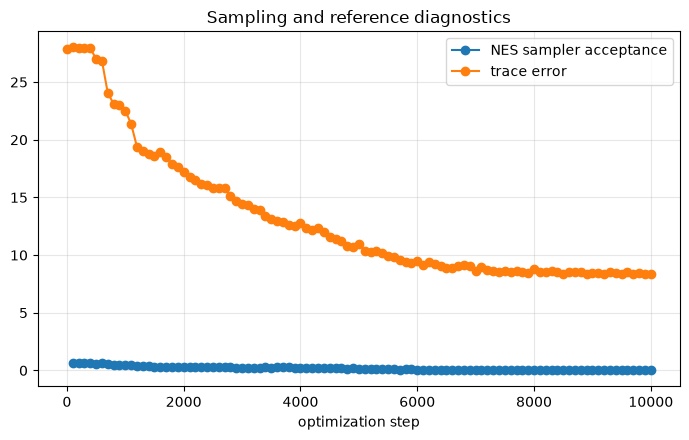

In [11]:
fig_diag


## Example B: 3x3 toric code, k=4, CNN

This is closer to the intended 2D usage. `shape=(3,3)` has `N_edges=18`, so exact evaluation over `2^18` configs is skipped by setting `eval_exact_if_sites_leq=12`. The analytic toric-code reference still gives the four degenerate ground energies `E=-18` for `Je=Jm=1`.


In [14]:
cfg = TrainConfig(
    shape=(4,4),
    hamiltonian='toric_code',
    k=5,
    Je=1.0,
    Jm=1.0,
    model='cnn',
    channels=(32, 32),
    kernel_size=3,
    steps=5000,
    lr=5e-3,
    n_chains=128,
    n_samples=8,
    print_every=100,
    eval_exact_if_sites_leq=12,
    eval_chains=128,
    eval_samples=32,
    reference='auto',
    seed=1,
)

params, history = train(cfg)

save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_2x2_k5_cnn.json'
save_history(history, save_path, cfg)

print('saved to:', save_path)


{'step': 0, 'loss_sum': -31.25815332266205, 'train_energy_estimator': nan, 'energies': [-16.028405503608045, -9.204824615440005, -6.486188461641584, 0.04411548800235518, 0.41714977002522874], 'reference': None, 'reference_source': 'own ED skipped because N=32 > max_sites=14', 'abs_errors': None, 'trace_error': None, 'condition_number_S': 999998.781762049, 'sampler_accept_rate': nan, 'grad_norm': nan, 'eval': {'accept_rate': 0.9997940063476562, 'burn_accept_rate': 0.9996337890625, 'S_min_eig': -1.244320995095834e-08, 'S_max_eig': 0.9999987817620489, 'S_rank': 1, 'S_floor': 1e-06, 'S_num_clipped': 4, 'S_eigenvalues': [-1.244320995095834e-08, 1.485825273937072e-08, 5.319431318051339e-07, 7.785712774397991e-07, 0.9999987817620489], 'method': 'sampled_span_q'}}
{'step': 100, 'loss_sum': -65.68045842377794, 'train_energy_estimator': -64.951904296875, 'energies': [-16.10546473537011, -12.981769738943786, -12.559183986091778, -12.086594034856883, -11.947445928515377], 'reference': None, 'refer

File:               /home/a/Anas.Roumeih/Desktop/Master Thesis/nes_lattice_project/results/sampled_nes_toric_2x2_k5_cnn.json
Config:             {'shape': [4, 4], 'hamiltonian': 'toric_code', 'k': 5, 'J': 1.0, 'g': 1.0, 'Je': 1.0, 'Jm': 1.0, 'pbc': True, 'magnetization': None, 'model': 'cnn', 'hidden': [64, 64], 'rbm_hidden': 32, 'channels': [32, 32], 'kernel_size': 3, 'init_scale': 0.05, 'dtype': 'float32', 'steps': 5000, 'lr': 0.005, 'n_chains': 128, 'n_samples': 8, 'sweep_steps': 32, 'burn_in': 320, 'det_jitter': 1e-06, 'grad_clip': 10.0, 'print_every': 100, 'eval_exact_if_sites_leq': 12, 'eval_samples': 32, 'eval_chains': 128, 'reference': 'auto', 'own_ed_max_sites': 14, 'netket_max_states': 2000000, 'jitter': 1e-06, 'seed': 1}
Final NES energies: [-38.97002243477079, -27.706233839535795, -16.394526865670894, -6.019970996660937, -4.882589837988739]
Reference:          None
Reference source:   own ED skipped because N=32 > max_sites=14
Abs errors:         None
Trace error:        No

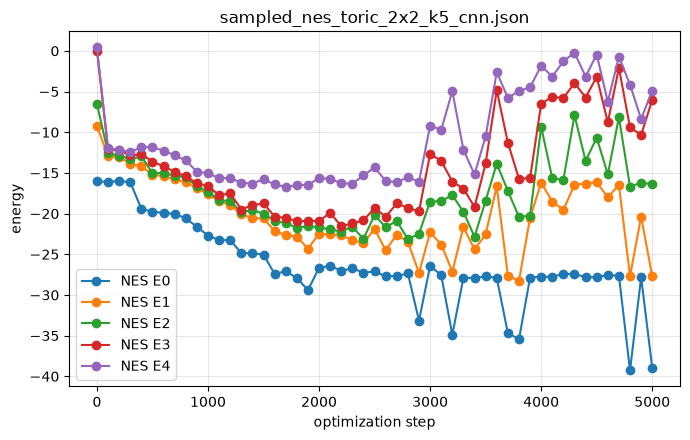

In [15]:
print_final(save_path)
fig, ax = plot_history(save_path)

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cuda"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import jax
import jax.numpy as jnp

print(jax.devices())

A = jnp.array([[2., 1.], [1., 2.]])
b = jnp.array([1., 0.])
print(jnp.linalg.solve(A, b).block_until_ready())

E0622 17:06:11.981306     618 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


[CudaDevice(id=0)]
[ 0.6666667  -0.33333334]


In [3]:
cfg = TrainConfig(
    shape=(4, 4),
    hamiltonian='toric_code',
    k=5,
    Je=1.0,
    Jm=1.0,
    model='cnn',
    channels=(16, 16),
    kernel_size=3,
    steps=7000,
    lr=5e-3,
    n_chains=128,
    n_samples=8,
    print_every=100,
    eval_exact_if_sites_leq=12,
    eval_chains=128,
    eval_samples=32,
    reference='auto',
    seed=1,
)

params, history = train(cfg)

save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_4x4_k5_cnn.json'
save_history(history, save_path, cfg)

print('saved to:', save_path)


{'step': 0, 'loss_sum': -22.946646180177297, 'train_energy_estimator': nan, 'energies': [-16.010760459975195, -5.691532287641637, -0.8873947517606987, -0.31530291976378405, -0.04165576103598328], 'reference': None, 'reference_source': 'own ED skipped because N=32 > max_sites=14', 'abs_errors': None, 'trace_error': None, 'condition_number_S': 999999.5842794953, 'sampler_accept_rate': nan, 'grad_norm': nan, 'eval': {'accept_rate': 0.9999237060546875, 'burn_accept_rate': 0.9999023675918579, 'S_min_eig': -3.21868851715594e-09, 'S_max_eig': 0.9999995842794952, 'S_rank': 1, 'S_floor': 1e-06, 'S_num_clipped': 4, 'S_eigenvalues': [-3.21868851715594e-09, 3.715027767661485e-08, 9.05741967146433e-08, 4.595955556851123e-07, 0.9999995842794952], 'method': 'sampled_span_q'}}
{'step': 100, 'loss_sum': -65.86170382042881, 'train_energy_estimator': -66.1591796875, 'energies': [-16.01619786674086, -13.120913282756431, -12.836798909998285, -11.974087987016157, -11.913705773917085], 'reference': None, 're

File:               /home/a/Anas.Roumeih/Desktop/Master Thesis/nes_lattice_project/results/sampled_nes_toric_4x4_k5_cnn.json
Config:             {'shape': [4, 4], 'hamiltonian': 'toric_code', 'k': 5, 'J': 1.0, 'g': 1.0, 'Je': 1.0, 'Jm': 1.0, 'pbc': True, 'magnetization': None, 'model': 'cnn', 'hidden': [64, 64], 'rbm_hidden': 32, 'channels': [16, 16], 'kernel_size': 3, 'init_scale': 0.05, 'dtype': 'float32', 'steps': 7000, 'lr': 0.005, 'n_chains': 128, 'n_samples': 8, 'sweep_steps': 32, 'burn_in': 320, 'det_jitter': 1e-06, 'grad_clip': 10.0, 'print_every': 100, 'eval_exact_if_sites_leq': 12, 'eval_samples': 32, 'eval_chains': 128, 'reference': 'auto', 'own_ed_max_sites': 14, 'netket_max_states': 2000000, 'jitter': 1e-06, 'seed': 1}
Final NES energies: [-27.89010262780161, -15.895793010425008, -4.390206209040593, -1.1506907105743047, -0.2035024205707822]
Reference:          None
Reference source:   own ED skipped because N=32 > max_sites=14
Abs errors:         None
Trace error:        N

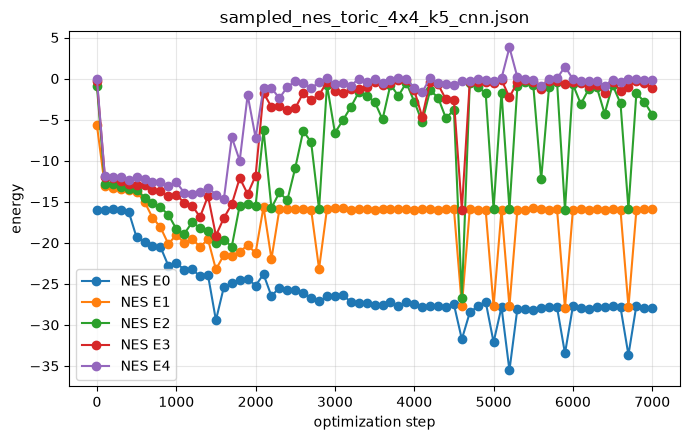

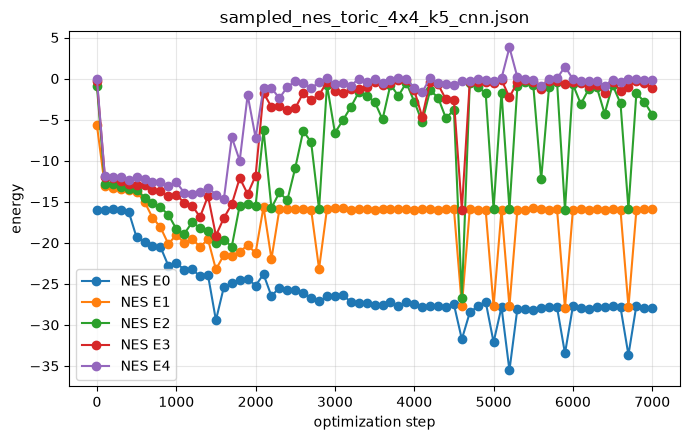

In [ ]:
---------------------------------------------------------------------------
JaxStackTraceBeforeTransformation         Traceback (most recent call last)
File /usr/lib64/python3.9/runpy.py:197, in _run_module_as_main()
    196     sys.argv[0] = mod_spec.origin
--> 197 return _run_code(code, main_globals, None,
    198                  "__main__", mod_spec)

File /usr/lib64/python3.9/runpy.py:87, in _run_code()
     80 run_globals.update(__name__ = mod_name,
     81                    __file__ = fname,
     82                    __cached__ = cached,
   (...)
     85                    __package__ = pkg_name,
     86                    __spec__ = mod_spec)
---> 87 exec(code, run_globals)
     88 return run_globals

File ~/venv/ferminet/lib/python3.9/site-packages/ipykernel_launcher.py:18
     16 from ipykernel import kernelapp as app
---> 18 app.launch_new_instance()

File ~/venv/ferminet/lib/python3.9/site-packages/traitlets/config/application.py:1082, in launch_instance()
   1081 app.initialize(argv)
-> 1082 app.start()

File ~/venv/ferminet/lib/python3.9/site-packages/ipykernel/kernelapp.py:739, in start()
    738 try:
--> 739     self.io_loop.start()
    740 except KeyboardInterrupt:

File ~/venv/ferminet/lib64/python3.9/site-packages/tornado/platform/asyncio.py:211, in start()
    210 def start(self) -> None:
--> 211     self.asyncio_loop.run_forever()

File /usr/lib64/python3.9/asyncio/base_events.py:601, in run_forever()
    600 while True:
--> 601     self._run_once()
    602     if self._stopping:

File /usr/lib64/python3.9/asyncio/base_events.py:1905, in _run_once()
   1904     else:
-> 1905         handle._run()
   1906 handle = None

File /usr/lib64/python3.9/asyncio/events.py:80, in _run()
     79 try:
---> 80     self._context.run(self._callback, *self._args)
     81 except (SystemExit, KeyboardInterrupt):

File ~/venv/ferminet/lib/python3.9/site-packages/ipykernel/kernelbase.py:519, in dispatch_queue()
    518 try:
--> 519     await self.process_one()
    520 except Exception:

File ~/venv/ferminet/lib/python3.9/site-packages/ipykernel/kernelbase.py:508, in process_one()
    506         self.control_stream.flush()
--> 508 await dispatch(*args)

File ~/venv/ferminet/lib/python3.9/site-packages/ipykernel/kernelbase.py:400, in dispatch_shell()
    399     if inspect.isawaitable(result):
--> 400         await result
    401 except Exception:

File ~/venv/ferminet/lib/python3.9/site-packages/ipykernel/ipkernel.py:368, in execute_request()
    367 self._associate_new_top_level_threads_with(parent_header)
--> 368 await super().execute_request(stream, ident, parent)

File ~/venv/ferminet/lib/python3.9/site-packages/ipykernel/kernelbase.py:767, in execute_request()
    766 if inspect.isawaitable(reply_content):
--> 767     reply_content = await reply_content
    769 # Flush output before sending the reply.

File ~/venv/ferminet/lib/python3.9/site-packages/ipykernel/ipkernel.py:455, in do_execute()
    454 if accepts_params["cell_id"]:
--> 455     res = shell.run_cell(
    456         code,
    457         store_history=store_history,
    458         silent=silent,
    459         cell_id=cell_id,
    460     )
    461 else:

File ~/venv/ferminet/lib/python3.9/site-packages/ipykernel/zmqshell.py:602, in run_cell()
    601 self._last_traceback = None
--> 602 return super().run_cell(*args, **kwargs)

File ~/venv/ferminet/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3048, in run_cell()
   3047 try:
-> 3048     result = self._run_cell(
   3049         raw_cell, store_history, silent, shell_futures, cell_id
   3050     )
   3051 finally:

File ~/venv/ferminet/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3103, in _run_cell()
   3102 try:
-> 3103     result = runner(coro)
   3104 except BaseException as e:

File ~/venv/ferminet/lib/python3.9/site-packages/IPython/core/async_helpers.py:129, in _pseudo_sync_runner()
    128 try:
--> 129     coro.send(None)
    130 except StopIteration as exc:

File ~/venv/ferminet/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3308, in run_cell_async()
   3305 interactivity = "none" if silent else self.ast_node_interactivity
-> 3308 has_raised = await self.run_ast_nodes(code_ast.body, cell_name,
   3309        interactivity=interactivity, compiler=compiler, result=result)
   3311 self.last_execution_succeeded = not has_raised

File ~/venv/ferminet/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3490, in run_ast_nodes()
   3489     asy = compare(code)
-> 3490 if await self.run_code(code, result, async_=asy):
   3491     return True

File ~/venv/ferminet/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3550, in run_code()
   3549     else:
-> 3550         exec(code_obj, self.user_global_ns, self.user_ns)
   3551 finally:
   3552     # Reset our crash handler in place

Cell In[1], line 12
     11 b = jnp.array([1., 0.])
---> 12 print(jnp.linalg.solve(A, b).block_until_ready())

File ~/venv/ferminet/lib/python3.9/site-packages/jax/_src/numpy/linalg.py:1349, in solve()
   1348   signature = "(m,m),(m,n)->(m,n)"
-> 1349 return jnp.vectorize(lax_linalg._solve, signature=signature)(a, b)

File ~/venv/ferminet/lib/python3.9/site-packages/jax/_src/numpy/vectorize.py:321, in wrapped()
    320     vectorized_func = api.vmap(vectorized_func, in_axes)
--> 321 result = vectorized_func(*squeezed_args)
    323 if not dims_to_expand:

File ~/venv/ferminet/lib/python3.9/site-packages/jax/_src/numpy/vectorize.py:138, in wrapped()
    137 def wrapped(*args):
--> 138   out = func(*args)
    139   out_shapes = map(jnp.shape, out if isinstance(out, tuple) else [out])

JaxStackTraceBeforeTransformation: RuntimeError: jaxlib/gpu/solver_kernels.cc:45: operation gpusolverDnCreate(&handle) failed: cuSolver internal error

The preceding stack trace is the source of the JAX operation that, once transformed by JAX, triggered the following exception.

--------------------

The above exception was the direct cause of the following exception:

RuntimeError                              Traceback (most recent call last)
Cell In[1], line 12
     10 A = jnp.array([[2., 1.], [1., 2.]])
     11 b = jnp.array([1., 0.])
---> 12 print(jnp.linalg.solve(A, b).block_until_ready())

    [... skipping hidden 20 frame]

File ~/venv/ferminet/lib64/python3.9/site-packages/jaxlib/gpu_solver.py:102, in _getrf_hlo(platform, gpu_blas, gpu_solver, dtype, a)
    100   kernel = f"{platform}blas_getrf_batched"
    101 else:
--> 102   lwork, opaque = gpu_solver.build_getrf_descriptor(
    103       np.dtype(dtype), batch, m, n)
    104   workspace = ir.RankedTensorType.get([lwork], a_type.element_type)
    105   kernel = f"{platform}solver_getrf"

RuntimeError: jaxlib/gpu/solver_kernels.cc:45: operation gpusolverDnCreate(&handle) failed: cuSolver internal error


In [ ]:
(fig_cond, ax_cond), (fig_diag, ax_diag) = plot_diagnostics(save_path)
fig_cond


In [ ]:
fig_diag


In [ ]:
cfg = TrainConfig(
    shape=(4, 4),
    hamiltonian="toric code",
    k=5,
    Je=1.0,
    Jm=1.0,

    model="rbm",
    rbm_hidden=128,   # try 64 first; later 128 if needed

    steps=7000,
    lr=2e-3,         # RBMs are usually less stable with 5e-3 here
    n_chains=96,
    n_samples=8,
    print_every=100,

    eval_exact_if_sites_leq=12,
    reference="auto",
    seed=0,
)

params, history = train(cfg)

save_path = PROJECT_ROOT / "results" / "sampled_nes_toric_4x4_k5_rbm_h64.json"
save_history(history, save_path, cfg)

print("saved to:", save_path)

{'step': 0, 'loss_sum': -63.49389694000159, 'train_energy_estimator': nan, 'energies': [-15.954990143441178, -12.088772643677503, -11.892063761172608, -11.814341029104641, -11.743729362605661], 'reference': None, 'reference_source': 'own ED skipped because N=32 > max_sites=14', 'abs_errors': None, 'trace_error': None, 'condition_number_S': 75.70347420137526, 'sampler_accept_rate': nan, 'grad_norm': nan, 'eval': {'accept_rate': 0.966400146484375, 'burn_accept_rate': 0.9660888910293579, 'S_min_eig': 0.012308336932461278, 'S_max_eig': 0.9317838674284166, 'S_rank': 5, 'S_floor': 1e-06, 'S_num_clipped': 0, 'S_eigenvalues': [0.012308336932461278, 0.01510242281618617, 0.016659306171994483, 0.02414605174978026, 0.9317838674284166], 'method': 'sampled_span_q'}}
{'step': 100, 'loss_sum': -63.600546920842504, 'train_energy_estimator': -63.883140563964844, 'energies': [-16.09044205925694, -12.010691137240785, -11.937059532710137, -11.884610044921954, -11.677744146712687], 'reference': None, 'refer

File:               /home/a/Anas.Roumeih/Desktop/Master Thesis/nes_lattice_project/results/sampled_nes_toric_4x4_k5_rbm_h64.json
Config:             {'shape': [4, 4], 'hamiltonian': 'toric_code', 'k': 5, 'J': 1.0, 'g': 1.0, 'Je': 1.0, 'Jm': 1.0, 'pbc': True, 'magnetization': None, 'model': 'rbm', 'hidden': [64, 64], 'rbm_hidden': 64, 'channels': [16, 16], 'kernel_size': 3, 'init_scale': 0.05, 'dtype': 'float32', 'steps': 7000, 'lr': 0.002, 'n_chains': 96, 'n_samples': 8, 'sweep_steps': 32, 'burn_in': 320, 'det_jitter': 1e-06, 'grad_clip': 10.0, 'print_every': 100, 'eval_exact_if_sites_leq': 12, 'eval_samples': 32, 'eval_chains': 128, 'reference': 'auto', 'own_ed_max_sites': 14, 'netket_max_states': 2000000, 'jitter': 1e-06, 'seed': 0}
Final NES energies: [-19.85286171480862, -14.605286435420687, -13.724154083527209, -7.186384579655698, -0.34055181174826266]
Reference:          None
Reference source:   own ED skipped because N=32 > max_sites=14
Abs errors:         None
Trace error:     

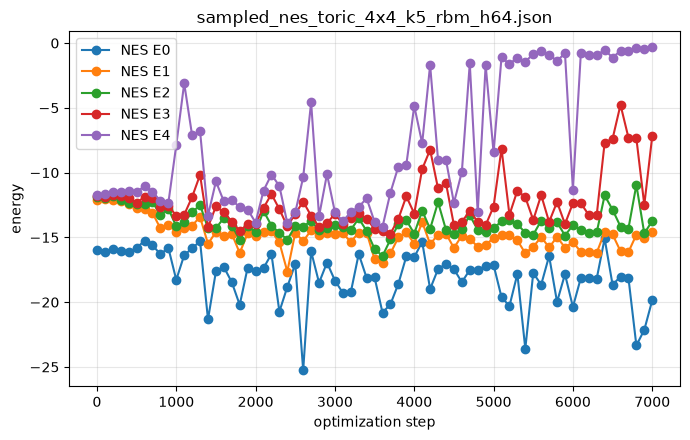

In [15]:
print_final(save_path)
fig, ax = plot_history(save_path)

# AFTER JITTER MODIFICATION